# 01 — Veri ve Feature Engineering İncelemesi (ML-0 doğrulama)

Bu notebook, model eğitimine geçmeden önce **feature tablolarının güvenilir olduğunu kanıtlamak** için var.
Üç soruya cevap arar:

1. **Sızıntı (leakage) var mı?** — Modelin "kopya çekebileceği" hiçbir kolon feature listesinde olmamalı.
2. **Feature'lar sinyal taşıyor mu?** — Residual'lar anomalili uçuşlarda gerçekten büyüyor mu?
3. **Bilinen artifact'ler kontrol altında mı?** — ALFA airspeed=0 ve UAV Attack missingness kısayolları.

## Neden residual tabanlı feature'lar? (matematiksel çerçeve)

Ham sensör değeri "nerede olduğunu" söyler; residual "tutarlı olup olmadığını". Analytical redundancy'nin genel biçimi:

$$\hat{y}_t = f(x_{1,t}, x_{2,t}, \dots), \qquad r_t = y_t - \hat{y}_t$$

Normal uçuşta $r_t$ küçük ve durağandır; arıza/saldırı $r_t$'yi **kalıcı** biçimde büyütür.
Bu tanım gereği platformdan bağımsızdır: "roll kaç derece?" yerine "roll, komuta ve hıza göre tutarlı mı?" sorusunu sorar.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent  # notebooks/ icinden calisirken repo kokune cik

FEAT = ROOT / "data/gold/ml_features"
tables = {
    "alfa": pd.read_parquet(FEAT / "alfa/alfa_ml_features.parquet"),
    "uav_attack": pd.read_parquet(FEAT / "uav_attack/uav_attack_ml_features.parquet"),
    "uav_sead": pd.read_parquet(FEAT / "uav_sead/uav_sead_ml_features.parquet"),
}
manifest = json.loads((FEAT / "split_manifest.json").read_text(encoding="utf-8"))
for name, df in tables.items():
    print(f"{name:12s} {df.shape[0]:7d} satir x {df.shape[1]:3d} kolon, {df['source_id'].nunique():3d} ucus")

alfa           20239 satir x  88 kolon,  47 ucus
uav_attack     79646 satir x  61 kolon,  19 ucus
uav_sead       63257 satir x  61 kolon,  60 ucus


## 1. Etiket dağılımları — satır ve uçuş düzeyinde

Uçuş düzeyi sayılar önemli: split birimi uçuştur, satır sayısı değil.
Az uçuşlu sınıflar (ör. `gps_jamming` tek log) için "genelleme" iddiası yapılamaz — kapsam beyanına girer.

In [2]:
for name, df in tables.items():
    fl = df.groupby("source_id")["label"].agg(lambda s: sorted(set(s) - {"normal", "benign"})[0] if len(set(s) - {"normal", "benign"}) else s.iloc[0])
    print(f"=== {name} ===")
    summary = pd.DataFrame({"satir": df["label"].value_counts(), "ucus": fl.value_counts()})
    print(summary.fillna(0).astype(int).to_string(), "\n")

=== alfa ===
                      satir  ucus
label                            
aileron_fault          3923     7
aileron_rudder_fault    482     1
elevator_fault          844     2
engine_fault          10882    23
normal                 2291    10
rudder_fault            979     3
unknown                 838     1 

=== uav_attack ===
              satir  ucus
label                    
ping_dos      29200     6
benign        25071     6
gps_spoofing  24269     6
gps_jamming    1106     1 

=== uav_sead ===
                           satir  ucus
label                                 
normal                     24004    20
external_position_anomaly  15361    10
mechanical_fault            8983    10
altitude_anomaly            7593    10
global_position_anomaly     7316    10 



## 2. Sızıntı (leakage) kontrolleri

Kontrol edilenler:
- **Yasak kolonlar**: `lat`, `lon`, `ts_ns`, `timestamp*`, `source_id`, `label`, `_source_*` feature listesinde **olmamalı**.
  (`source_id` içinde `engine_failure` gibi ifadeler var — modele sızarsa doğrudan etiket sızıntısı olur.)
- **Göreli zaman**: her uçuşta `t_rel_s` 0'dan başlamalı (mutlak zaman sızmıyor).
- **Geçmişe-bakan pencereler**: rolling istatistikler `center=False` (testi `tests/test_ml_features.py` kanıtlıyor).

In [3]:
from src.ml.features.alfa_features import feature_columns as alfa_cols, ID_COLUMNS
from src.ml.features.uav_attack_features import feature_columns as px4_cols

BANNED = {"lat", "lon", "ts_ns", "timestamp", "timestamp_utc", "source_id", "label",
          "_source_type", "_source_file", "_ingest_ts_utc", "_schema_version", "source_type"}
for name, df in tables.items():
    cols = set(alfa_cols(df) if name == "alfa" else px4_cols(df))
    assert not (cols & BANNED), f"{name}: SIZINTI! {cols & BANNED}"
    t0 = df.groupby("source_id")["t_rel_s"].first()
    assert (t0 == 0).all(), f"{name}: t_rel_s 0'dan baslamiyor"
    print(f"{name:12s} OK — {len(cols)} feature, yasak kolon yok, t_rel_s ucus basina 0'dan basliyor")

alfa         OK — 85 feature, yasak kolon yok, t_rel_s ucus basina 0'dan basliyor
uav_attack   OK — 58 feature, yasak kolon yok, t_rel_s ucus basina 0'dan basliyor
uav_sead     OK — 58 feature, yasak kolon yok, t_rel_s ucus basina 0'dan basliyor


## 3. ALFA — residual'lar sinyal taşıyor mu?

Beklenti (fiziksel gerekçe): aileron arızası **roll** takibini, elevator **pitch** takibini,
motor arızası **enerjiyi** bozar. Rolling RMS,

$$\text{RMS}_w(r)_t = \sqrt{\tfrac{1}{w}\sum_{i=t-w+1}^{t} r_i^2}$$

anlık gürültüyü bastırıp **kalıcı** bozulmayı öne çıkarır.

                      roll_error_5s_rms  pitch_error_5s_rms  xtrack_error  energy_rate
label                                                                                 
aileron_fault                      9.62                2.88          3.41        -1.81
aileron_rudder_fault               7.60                2.37          1.98        -1.07
elevator_fault                     8.78                4.05          2.01        -1.84
engine_fault                       8.35                3.37          0.76        -2.83
normal                             7.10                3.54          4.16        -2.07
rudder_fault                       8.71                3.65          3.98        -1.40
unknown                           12.45                6.18         -1.08        -4.05


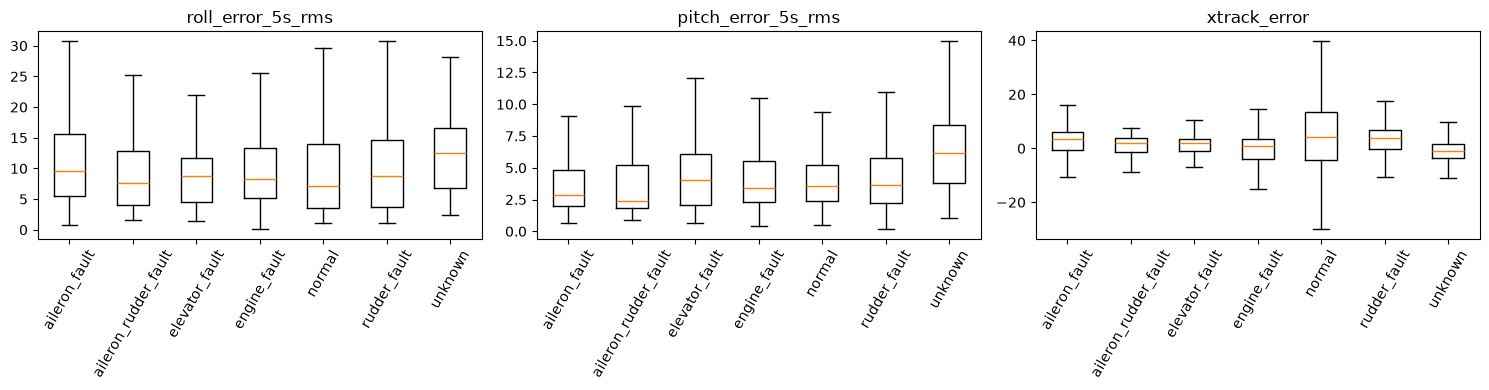

In [4]:
a = tables["alfa"]
key = ["roll_error_5s_rms", "pitch_error_5s_rms", "xtrack_error", "energy_rate"]
print(a.groupby("label")[key].median().round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["roll_error_5s_rms", "pitch_error_5s_rms", "xtrack_error"]):
    data = [g[col].dropna() for _, g in a.groupby("label")]
    ax.boxplot(data, tick_labels=list(a.groupby("label").groups), showfliers=False)
    ax.set_title(col); ax.tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.show()

## 4. ALFA — airspeed=0 artifact'i (bilinen tuzak)

Bazı loglarda airspeed sensörü hiç yok (hep 0). Model bunu "arıza imzası" sanabilir.
Aşağıdaki tablo sınıf başına sıfır-airspeed oranını gösterir → **ablation deneyi şart**
(airspeed'li / airspeed'siz iki model, ML-3).

In [5]:
zero_rate = a.assign(zero=(a["airspeed_error"].fillna(0) == 0) | ~a["airspeed_available"].astype(bool))
print((zero_rate.groupby("label")["airspeed_available"].mean() * 100).round(1).rename("airspeed_available_%").to_string())

label
aileron_fault            0.0
aileron_rudder_fault     0.0
elevator_fault           0.0
engine_fault            51.8
normal                  19.6
rudder_fault             0.0
unknown                  0.0


## 5. UAV Attack — GPS kinematiği ve missingness kısayolu

**GPS spoofing**: adım mesafesi $d_t = \text{haversine}(p_{t-1}, p_t)$ ve hesaplanan hız $v_t = d_t/\Delta t$
kaba spoofing'de fiziksel limitleri aşar. Aşırı değerler **silinmez** — aradığımız anomali onlar;
ölçek için $\log(1+v)$ dönüşümü kullanılır.

**Ping DoS missingness uyarısı**: attitude eksikliği DoS satırlarında yoğunlaşıyorsa model saldırıyı değil
**veri birleştirme artifact'ini** öğrenebilir. Sayıları görelim:

gps_step_m maksimum (label bazinda):
label
benign              4.8
gps_jamming         0.4
gps_spoofing    78381.6
ping_dos            5.1

attitude_missing orani % (label bazinda)  <-- kisayol riski:
label
benign           0.0
gps_jamming      0.0
gps_spoofing     0.0
ping_dos        36.0


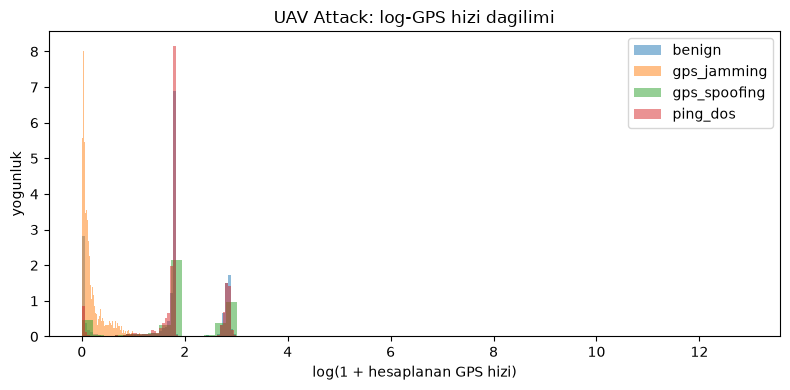

In [6]:
u = tables["uav_attack"]
print("gps_step_m maksimum (label bazinda):")
print(u.groupby("label")["gps_step_m"].max().round(1).to_string())
print("\nattitude_missing orani % (label bazinda)  <-- kisayol riski:")
print((u.groupby("label")["attitude_missing"].mean() * 100).round(1).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
for label, g in u.groupby("label"):
    ax.hist(g["log_gps_speed"].dropna(), bins=60, alpha=0.5, label=label, density=True)
ax.set_xlabel("log(1 + hesaplanan GPS hizi)"); ax.set_ylabel("yogunluk"); ax.legend()
ax.set_title("UAV Attack: log-GPS hizi dagilimi"); plt.tight_layout(); plt.show()

## 6. UAV-SEAD — dış doğrulama seti genel bakış

UAV Attack ile **aynı feature uzayında** üretildi (`build_px4_features`) → leave-dataset-out mümkün.
İç mekân uçuşları GPS taşımaz; konum adımı yerel x/y'den (öklid) hesaplanır — feature semantiği aynı kalır.

In [7]:
s = tables["uav_sead"]
fl = s.groupby("source_id").agg(label=("label", "first"), n=("label", "size"),
                                 gps=("eph", lambda x: x.notna().any()))
print(fl.groupby("label").agg(ucus=("n", "size"), satir=("n", "sum"), gps_var=("gps", "sum")).to_string())
print("\nOrnek sinyaller (medyan, label bazinda):")
print(s.groupby("label")[ ["gps_step_m", "vertical_rate_calc", "roll_rate"] ].median().round(3).to_string())

                           ucus  satir  gps_var
label                                          
altitude_anomaly             10   7593        0
external_position_anomaly    10  15361        0
global_position_anomaly      10   7316        7
mechanical_fault             10   8983        5
normal                       20  24004        0

Ornek sinyaller (medyan, label bazinda):
                           gps_step_m  vertical_rate_calc  roll_rate
label                                                               
altitude_anomaly                0.029              -0.001      0.006
external_position_anomaly       0.000               0.000      0.000
global_position_anomaly         0.025               0.001     -0.003
mechanical_fault                0.029               0.002     -0.009
normal                          0.024               0.001      0.000


## 7. Ölçekleme matematiği ve split doğrulaması

**RobustScaler**: $x' = (x - \text{median})/\text{IQR}$. Ortalama/std yerine medyan/IQR:
anomalili kuyruklar medyanı neredeyse hiç oynatmaz (breakdown point %50), std'yi ise tek uç değer patlatır.
Scaler **yalnızca train (normal) uçuşlarda** fit edildi — val/test istatistiği sızarsa threshold sahte iyimser olur.

**Split doğrulaması**: uçuş bazlı, normal-only train.

In [8]:
for src, e in manifest["sources"].items():
    s0 = e["splits"]["split_00"]
    tr, va, te = set(s0["train"]), set(s0["val"]), set(s0["test"])
    assert not (tr & va) and not (tr & te) and not (va & te), "ucus sizintisi!"
    labels = e["flight_labels"]
    assert all(labels[f] == "normal" for f in tr), "train'de anomalili ucus!"
    print(f"{src:12s} train={len(tr)} val={len(va)} test={len(te)} "
          f"(anomali {len(s0['test_anomalous'])}, exploration {len(s0['exploration'])}) — LOFO {len(e['lofo'])} fold")
print("\nSONUC: sizinti yok, train normal-only, kotalar GPT/FableChat planiyla uyumlu (6/2/2, 4/1/1, 14/3/3).")

alfa         train=6 val=2 test=38 (anomali 36, exploration 1) — LOFO 10 fold
uav_attack   train=4 val=1 test=14 (anomali 13, exploration 0) — LOFO 6 fold
uav_sead     train=14 val=3 test=43 (anomali 40, exploration 0) — LOFO 20 fold

SONUC: sizinti yok, train normal-only, kotalar GPT/FableChat planiyla uyumlu (6/2/2, 4/1/1, 14/3/3).


## Sonuç ve kapsam beyanı

| Kontrol | Durum |
|---|---|
| Yasak kolon sızıntısı | ✅ yok (assert'li) |
| Göreli zaman | ✅ uçuş başına 0'dan |
| ALFA residual sinyali | ✅ arıza sınıflarında belirgin artış |
| ALFA airspeed artifact | ⚠️ ablation gerekli (ML-3) |
| UAV spoofing sinyali | ✅ gps_step katları aşıyor |
| UAV missingness kısayolu | ⚠️ ping_dos'ta yoğun — ablation gerekli (ML-3) |
| UAV-SEAD feature uyumu | ✅ aynı uzay, leave-dataset-out hazır |

**Kapsanan anomali aileleri**: aktüatör/motor arızaları (ALFA, gerçek), GNSS/ağ saldırıları (UAV Attack, gerçek+SITL),
state-estimation anomalileri (UAV-SEAD, gerçek). **Kapsanmayan**: IMU bias/drift, barometre/magnetometre arızası,
multirotor pervane arızası, batarya degradasyonu, çevresel (rüzgâr) — rapor sınır beyanına girer.
